# 03. Desarrollo y prueba del pipeline completo

Recorre los 11 bloques del pipeline (`preprocessing` → `balancing` → `models` → `optimization` → `nested_cv` → `experiment_runner` → `complexity_analysis` → `evaluation` → `interpretability` → `stats_comparison`) con **datos sintéticos y configuraciones pequeñas** (pocos folds, pocas iteraciones), para validar rápido que todo sigue funcionando junto después de cualquier cambio de código.

**No reemplaza** a `04_run_experiments.ipynb` (la corrida real con el dataset final): este notebook escribe en `results/dev_pipeline_check.csv` (gitignored, throwaway), nunca en `results/experiments_master.csv`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold

from src import config
from src.synthetic_data import generate_synthetic_dataset
from src.data_loader import split_features_target
from src.preprocessing import remove_duplicate_rows, get_preprocessing_steps, build_column_transformer
from src.models import MODEL_REGISTRY, get_model_names, get_param_grid
from src.balancing import get_compatible_techniques, build_pipeline
from src.optimization import run_optimization, OPTIMIZATION_METHODS
from src.nested_cv import run_nested_cv
from src.experiment_runner import run_experiments
from src.complexity_analysis import compare_standard_vs_optimized, select_best_fold_index
from src.evaluation import pooled_predictions, pooled_roc_curve, evaluate_calibration, is_calibration_poor
from src import interpretability as ip
from src import stats_comparison as sc

np.random.seed(config.RANDOM_STATE)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Datos sintéticos (bloque 1)

In [2]:
df = generate_synthetic_dataset(n_samples=500)
df, n_removed = remove_duplicate_rows(df)
X, y = split_features_target(df)
print(f"X: {X.shape}, filas duplicadas eliminadas: {n_removed}")
print(f"Balance del target: {y.value_counts(normalize=True).round(3).to_dict()}")

X: (500, 20), filas duplicadas eliminadas: 0
Balance del target: {0: 0.766, 1: 0.234}


## 2. Preprocesamiento: encoding + scaling condicional

`SEX`/`EDUCATION`/`MARRIAGE` (o sus equivalentes sintéticos) se codifican one-hot; el resto se escala solo si el modelo lo requiere (`ModelSpec.requires_scaling`).

In [3]:
spec_scaled = MODEL_REGISTRY["logistic_regression"]  # requires_scaling=True
ct = build_column_transformer(apply_scaling=spec_scaled.requires_scaling)
Xt = ct.fit_transform(X)
print(f"Columnas originales: {X.shape[1]} -> transformadas (one-hot + scaling): {Xt.shape[1]}")

Columnas originales: 20 -> transformadas (one-hot + scaling): 25


## 3. Balanceo: compatibilidad por modelo (bloque 3)

KNN y Naive Bayes no soportan `class_weight`, deben aparecer con solo 3 técnicas.

In [4]:
for name, spec in MODEL_REGISTRY.items():
    print(f"  {name}: {get_compatible_techniques(spec)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=config.RANDOM_STATE
)

demo_spec = MODEL_REGISTRY["decision_tree"]
for technique in get_compatible_techniques(demo_spec):
    steps = get_preprocessing_steps(demo_spec)
    pipe = build_pipeline(demo_spec, technique, y_train=y_train, preprocessing_steps=steps)
    pipe.fit(X_train, y_train)
    assert len(pipe.predict(X_test)) == len(X_test)
print(f"\nOK: {demo_spec.name} entrenado con sus {len(get_compatible_techniques(demo_spec))} técnicas compatibles.")

  knn: ['none', 'smote', 'adasyn', 'class_weight']
  naive_bayes: ['none', 'smote', 'adasyn', 'class_weight']
  logistic_regression: ['none', 'smote', 'adasyn', 'class_weight']
  decision_tree: ['none', 'smote', 'adasyn', 'class_weight']
  random_forest: ['none', 'smote', 'adasyn', 'class_weight']
  xgboost: ['none', 'smote', 'adasyn', 'class_weight']
  svm: ['none', 'smote', 'adasyn', 'class_weight']



OK: decision_tree entrenado con sus 4 técnicas compatibles.


## 4. Modelos base y espacios de búsqueda (bloque 2)

In [5]:
print("Modelos registrados:", get_model_names())
print("param_grid (decision_tree):", get_param_grid(demo_spec))

Modelos registrados: ['knn', 'naive_bayes', 'logistic_regression', 'decision_tree', 'random_forest', 'xgboost', 'svm']
param_grid (decision_tree): {'max_depth': [2, 11, 21, 30], 'min_samples_split': [2, 18, 34, 50], 'min_samples_leaf': [1, 7, 14, 20], 'criterion': ['gini', 'entropy']}


## 5. Optimización: los 4 métodos, en miniatura (bloque 4)

Mismo modelo/técnica para los 4, con presupuestos diminutos (esto es una prueba de humo, no una búsqueda real).

In [6]:
inner_cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=config.RANDOM_STATE)
opt_kwargs = {
    "grid_search": {},
    "random_search": {"n_iter": 5},
    "bayesian_optuna": {"n_trials": 5},
    "genetic_deap": {"population_size": 6, "n_generations": 3},
}

ga_diversity = None
for method in OPTIMIZATION_METHODS:
    result = run_optimization(
        method, demo_spec, "class_weight", X_train, y_train, inner_cv,
        preprocessing_steps=get_preprocessing_steps(demo_spec), **opt_kwargs[method],
    )
    print(f"  {method}: best_score={result.best_score:.4f}, n_evaluations={result.n_evaluations}")
    if method == "genetic_deap":
        ga_diversity = result.diagnostics["diversity_history"]

  grid_search: best_score=0.5571, n_evaluations=128
  random_search: best_score=0.5596, n_evaluations=5


  bayesian_optuna: best_score=0.5475, n_evaluations=5


  genetic_deap: best_score=0.5685, n_evaluations=12


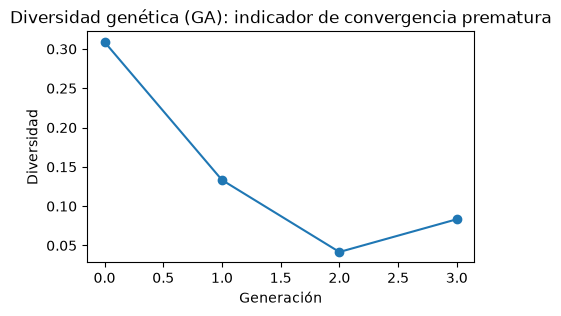

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(ga_diversity, marker="o")
ax.set_xlabel("Generación"); ax.set_ylabel("Diversidad")
ax.set_title("Diversidad genética (GA): indicador de convergencia prematura")
plt.savefig(config.FIGURES_DIR / "dev_ga_diversity.png", dpi=100, bbox_inches="tight")
plt.show()

## 6. Validación cruzada anidada: inner vs. outer (bloque 5)

El punto clave a verificar: `inner_best_score` (validación interna) y la métrica del outer fold son números DISTINTOS, nunca deben confundirse.

In [8]:
ncv_result = run_nested_cv(
    demo_spec, "class_weight", "random_search", X, y,
    n_outer_folds=2, n_inner_folds=2, optimizer_kwargs={"n_iter": 5},
)
for fr in ncv_result.fold_results:
    print(
        f"  fold {fr.fold_index}: inner_best_score={fr.inner_best_score:.4f}  "
        f"outer f1={fr.metrics['f1']:.4f}  (nunca confundir estos dos)"
    )
print("metrics_summary:", {k: (round(v[0], 4), round(v[1], 4)) for k, v in ncv_result.metrics_summary.items()})

  fold 0: inner_best_score=0.4070  outer f1=0.5032  (nunca confundir estos dos)
  fold 1: inner_best_score=0.5680  outer f1=0.5333  (nunca confundir estos dos)
metrics_summary: {'accuracy': (0.72, 0.028), 'precision': (0.4379, 0.0358), 'recall': (0.6413, 0.0311), 'f1': (0.5183, 0.0151), 'roc_auc': (0.7229, 0.015)}


## 7. Orquestador: unas pocas combinaciones (bloque 6)

Checkpoint DEDICADO a desarrollo (`results/dev_pipeline_check.csv`, gitignored), nunca toca `results/experiments_master.csv`.

In [9]:
dev_checkpoint = config.RESULTS_DIR / "dev_pipeline_check.csv"

models_dev = [MODEL_REGISTRY["decision_tree"], MODEL_REGISTRY["logistic_regression"]]
table, results = run_experiments(
    X, y,
    models=models_dev, techniques=["none", "class_weight"], methods=["random_search"],
    n_outer_folds=2, n_inner_folds=2,
    optimizer_kwargs_by_method={"random_search": {"n_iter": 5}},
    checkpoint_path=dev_checkpoint, resume=False, n_jobs=1,
)
table[["model", "technique", "method", "f1_mean", "f1_std"]]

[experiment_runner] 4 combinaciones a ejecutar.


C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

[experiment_runner] OK logistic_regression/none/random_search — f1=0.5299±0.0415 (0.5s)


C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1407: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use

C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\valef\anaconda3\envs\creditcard\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\valef\anaconda3\env

[experiment_runner] OK logistic_regression/class_weight/random_search — f1=0.5524±0.0402 (0.4s)


[experiment_runner] OK decision_tree/none/random_search — f1=0.5547±0.0547 (0.3s)


[experiment_runner] OK decision_tree/class_weight/random_search — f1=0.5183±0.0151 (0.3s)


,model,technique,method,f1_mean,f1_std
0,logistic_regression,none,random_search,0.529900,0.041528
1,logistic_regression,class_weight,random_search,0.552394,0.040199
2,decision_tree,none,random_search,0.554688,0.054688
3,decision_tree,class_weight,random_search,0.518280,0.015054


## 8. Complejidad computacional: estándar vs. optimizado (bloque 7)

In [10]:
dt_result = results[("decision_tree", "class_weight", "random_search")]
fold_idx = select_best_fold_index(dt_result, metric="f1")
best_params = dt_result.fold_results[fold_idx].best_params

complexity_row = compare_standard_vs_optimized(
    MODEL_REGISTRY["decision_tree"], "class_weight", best_params, X, y, fold_idx, n_outer_folds=2,
)
print(f"Cambio en desempeño (optimizado - estándar): {complexity_row['performance_change']:.4f}")

Cambio en desempeño (optimizado - estándar): 0.0379


## 9. Evaluación y calibración (bloque 8)

In [11]:
y_true_p, y_pred_p, y_proba_p = pooled_predictions(dt_result)
roc = pooled_roc_curve(dt_result)
calib = evaluate_calibration(y_true_p, y_proba_p, n_bins=5)

print(f"AUC (out-of-fold pooleado): {roc['auc']:.4f}")
print(f"Brier: {calib['brier_score']:.4f}  ECE: {calib['ece']:.4f}  (deficiente: {is_calibration_poor(calib['ece'])})")

AUC (out-of-fold pooleado): 0.7231
Brier: 0.2087  ECE: 0.2208  (deficiente: True)


## 10. Interpretabilidad: SHAP rápido (bloque 9)

In [12]:
fitted = ip.fit_explainable_pipeline(
    MODEL_REGISTRY["decision_tree"], "class_weight", best_params, X, y, fold_idx, n_outer_folds=2
)
model_step = fitted["pipeline"].named_steps["model"]
n_explain = min(50, fitted["X_test_t"].shape[0])

shap_values, base_value = ip.compute_shap_values(
    "decision_tree", model_step, fitted["X_train_t"], fitted["X_test_t"][:n_explain]
)
agg_values, agg_names = ip.aggregate_onehot_shap(shap_values, fitted["feature_names"])
print(f"SHAP agregado: {agg_values.shape}, primeras features: {agg_names[:5]}")

SHAP agregado: (50, 20), primeras features: ['SEX', 'EDUCATION', 'MARRIAGE', 'feature_0', 'feature_2']


## 11. Comparación estadística jerárquica (bloque 10, mini)

Con tan pocas combinaciones/folds de prueba (solo para validar que el código corre), es normal y esperado que Friedman NO dé significativo (ver la limitación de potencia estadística documentada en `stats_comparison.py`).

In [13]:
comparison = sc.run_hierarchical_comparison(results, metric="f1", top_k_for_delong=2)
friedman = comparison["friedman"]
print(f"Friedman: p={friedman['p_value']:.4f}, significativo={friedman['significant']}")
if not friedman["significant"]:
    print(comparison.get("stage_2_note", ""))

Friedman: p=0.7530, significativo=False
Friedman no significativo (p=0.7530 >= alpha=0.05): no se reporta evidencia de superioridad de ninguna combinación. Dado que N_OUTER_FOLDS=3 (pocos bloques), esto puede reflejar falta de potencia estadística tanto como equivalencia real — ver limitación documentada en el docstring del módulo.


## Listo

Los 11 bloques corrieron de punta a punta sin errores. Para la corrida real (dataset final, ~104 combinaciones): `04_run_experiments.ipynb`.